In [1]:
# Mount Drive and verify all inputs exist
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import numpy as np

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

STGCN_CKPT      = '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30_70_10_20/best_stgcn_hri30.pt'
CTRGCN_CKPT     = '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30_70_10_20/best_ctrgcn_hri30.pt'

STGCN_TEST_DATA  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/test_label.pkl'
CTRGCN_TEST_NPZ  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/ctrgcn_format/HRI30_CS.npz'

OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/temporal_truncation'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\nOutput folder ready: {OUTPUT_DIR}")

checks = [
    ("ST-GCN checkpoint",  STGCN_CKPT),
    ("CTR-GCN checkpoint", CTRGCN_CKPT),
    ("ST-GCN test data",   STGCN_TEST_DATA),
    ("ST-GCN test labels", STGCN_TEST_LABEL),
    ("CTR-GCN npz",        CTRGCN_TEST_NPZ),
]

all_ok = True
print("\n--- File verification ---")
for name, path in checks:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        print(f"  OK  {name}: {size_mb:.1f} MB")
    else:
        print(f"  MISSING  {name}: {path}")
        all_ok = False

if all_ok:
    print("\nAll inputs found.")
else:
    print("\nFix missing files before continuing.")

Mounted at /content/drive
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

Output folder ready: /content/drive/MyDrive/HRC_Research/results/temporal_truncation

--- File verification ---
  OK  ST-GCN checkpoint: 11.9 MB
  OK  CTR-GCN checkpoint: 5.8 MB
  OK  ST-GCN test data: 25.2 MB
  OK  ST-GCN test labels: 0.0 MB
  OK  CTR-GCN npz: 126.2 MB

All inputs found.


In [2]:
# Clone repos, patch, and load both fine-tuned HRI30 models (70/10/20 Weights)
import os
import sys
import torch
import torch.nn as nn
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type != 'cuda':
    print("WARNING: No GPU detected. Inference will be slow on CPU. "
          "Runtime > Change runtime type > T4 GPU.")

STGCN_DIR  = '/content/st-gcn'
CTRGCN_DIR = '/content/CTR-GCN'

if not os.path.exists(STGCN_DIR):
    os.system(f'git clone https://github.com/yysijie/st-gcn.git {STGCN_DIR}')
    print("ST-GCN cloned.")
else:
    print("ST-GCN already present.")

stgcn_io = Path(f'{STGCN_DIR}/torchlight/torchlight/io.py')
text = stgcn_io.read_text()
if 'weights_only=False' not in text:
    text = text.replace(
        'torch.load(weights_path)',
        'torch.load(weights_path, weights_only=False, map_location="cpu")'
    )
    stgcn_io.write_text(text)
    print("ST-GCN torch.load patch applied.")
else:
    print("ST-GCN patch already present.")

os.system(f'pip install -e {STGCN_DIR}/torchlight -q')

if not os.path.exists(CTRGCN_DIR):
    os.system(f'git clone https://github.com/Uason-Chen/CTR-GCN.git {CTRGCN_DIR}')
    print("CTR-GCN cloned.")
else:
    print("CTR-GCN already present.")

os.system('pip install -q tensorboardX torchpack fvcore iopath yacs thop')
os.system(f'pip install -e {CTRGCN_DIR}/torchlight -q')

ctrgcn_util = Path(f'{CTRGCN_DIR}/torchlight/torchlight/util.py')
text = ctrgcn_util.read_text()
if 'PaviLogger = None' not in text:
    text = text.replace(
        'from torchpack.runner.hooks import PaviLogger',
        'try:\n    from torchpack.runner.hooks import PaviLogger\nexcept ImportError:\n    PaviLogger = None'
    )
    ctrgcn_util.write_text(text)
    print("CTR-GCN torchpack patch applied.")
else:
    print("CTR-GCN patch already present.")

sys.path.insert(0, STGCN_DIR)
from net.st_gcn import Model as STGCN_Model

stgcn_model = STGCN_Model(
    in_channels=3,
    num_class=30,
    dropout=0.5,
    edge_importance_weighting=True,
    graph_args={'layout': 'ntu-rgb+d', 'strategy': 'spatial'}
)


stgcn_ckpt = torch.load(
    '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30_70_10_20/best_stgcn_hri30.pt',
    map_location='cpu', weights_only=False
)
stgcn_state = stgcn_ckpt['model_state_dict'] if isinstance(stgcn_ckpt, dict) and 'model_state_dict' in stgcn_ckpt else stgcn_ckpt
stgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in stgcn_state.items()}
stgcn_model.load_state_dict(stgcn_state, strict=True)
stgcn_model = stgcn_model.to(device)
stgcn_model.eval()
print("ST-GCN loaded (30 classes) - 70/10/20 Weights ✓")

sys.path.insert(0, CTRGCN_DIR)
from model.ctrgcn import Model as CTRGCN_Model

ctrgcn_model = CTRGCN_Model(
    num_class=30,
    num_point=25,
    num_person=1,
    graph='graph.ntu_rgb_d.Graph',
    graph_args={'labeling_mode': 'spatial'}
)


ctrgcn_ckpt = torch.load(
    '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30_70_10_20/best_ctrgcn_hri30.pt',
    map_location='cpu', weights_only=False
)
ctrgcn_state = ctrgcn_ckpt['model_state_dict'] if isinstance(ctrgcn_ckpt, dict) and 'model_state_dict' in ctrgcn_ckpt else ctrgcn_ckpt
ctrgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in ctrgcn_state.items()}
ctrgcn_model.load_state_dict(ctrgcn_state, strict=True)
ctrgcn_model = ctrgcn_model.to(device)
ctrgcn_model.eval()
print("CTR-GCN loaded (30 classes) - 70/10/20 Weights ✓")

print("\nBoth models ready. ")

Using device: cuda
ST-GCN cloned.
ST-GCN torch.load patch applied.
CTR-GCN cloned.
CTR-GCN torchpack patch applied.
ST-GCN loaded (30 classes) - 70/10/20 Weights ✓
CTR-GCN loaded (30 classes) - 70/10/20 Weights ✓

Both models ready. 


In [3]:
# Load test data for both models and verify shapes
import numpy as np
import pickle

STGCN_TEST_DATA  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/test_label.pkl'
CTRGCN_TEST_NPZ  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/ctrgcn_format/HRI30_CS.npz'

stgcn_test_data = np.load(STGCN_TEST_DATA)

with open(STGCN_TEST_LABEL, 'rb') as f:
    _, y_test = pickle.load(f)
stgcn_test_labels = np.array(y_test)

print(f"ST-GCN test data shape:   {stgcn_test_data.shape}")
print(f"ST-GCN test labels shape: {stgcn_test_labels.shape}")
print(f"ST-GCN label range:       {stgcn_test_labels.min()} to {stgcn_test_labels.max()}")

npz = np.load(CTRGCN_TEST_NPZ)
ctrgcn_test_data   = npz['x_test']
ctrgcn_test_labels = npz['y_test']

print(f"\nCTR-GCN test data shape:   {ctrgcn_test_data.shape}")
print(f"CTR-GCN test labels shape: {ctrgcn_test_labels.shape}")
print(f"CTR-GCN label range:       {ctrgcn_test_labels.min()} to {ctrgcn_test_labels.max()}")

assert stgcn_test_data.shape[0] == ctrgcn_test_data.shape[0], \
    f"Sample mismatch: ST-GCN {stgcn_test_data.shape[0]} vs CTR-GCN {ctrgcn_test_data.shape[0]}"
assert (stgcn_test_labels == ctrgcn_test_labels).all(), \
    "Label mismatch between ST-GCN and CTR-GCN test sets!"

T_total = stgcn_test_data.shape[2]
print(f"\nSequence length T = {T_total} frames")
print(f"Truncation points that will be tested:")
for ratio in [0.20, 0.30, 0.50, 1.00]:
    k = max(1, int(round(T_total * ratio)))
    print(f"  {int(ratio*100):>3}%  →  first {k} frames visible, {T_total - k} frames zeroed")

print(f"\n{stgcn_test_data.shape[0]} test samples, 30 classes, labels match.")

ST-GCN test data shape:   (588, 3, 150, 25, 1)
ST-GCN test labels shape: (588,)
ST-GCN label range:       0 to 29

CTR-GCN test data shape:   (588, 3, 150, 25, 1)
CTR-GCN test labels shape: (588,)
CTR-GCN label range:       0 to 29

Sequence length T = 150 frames
Truncation points that will be tested:
   20%  →  first 30 frames visible, 120 frames zeroed
   30%  →  first 45 frames visible, 105 frames zeroed
   50%  →  first 75 frames visible, 75 frames zeroed
  100%  →  first 150 frames visible, 0 frames zeroed

588 test samples, 30 classes, labels match.


In [4]:
# Temporal Truncation Experiment (N=30 TRIALS for Variance)
import torch
import numpy as np
import csv
import os
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/temporal_truncation'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def apply_temporal_truncation(data_np, ratio):
    data_out = data_np.copy()
    T = data_out.shape[2]
    keep = max(1, int(round(T * ratio)))
    data_out[:, :, keep:, :, :] = 0.0
    return data_out

def get_model_logits(model, data_np, batch_size=64):
    model.eval()
    all_logits = []
    N = data_np.shape[0]
    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            batch = torch.tensor(data_np[start:end], dtype=torch.float32).to(device)
            output = model(batch)
            all_logits.append(output.cpu().numpy())
    return np.concatenate(all_logits)

def softmax(logits):
    exp_x = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def entropy(probs):
    return -np.sum(probs * np.log(probs + 1e-9), axis=1)

def consensus_fusion(logits_st, logits_ctr):
    probs_st  = softmax(logits_st)
    probs_ctr = softmax(logits_ctr)
    H_st  = entropy(probs_st)
    H_ctr = entropy(probs_ctr)
    W_st  = np.exp(-H_st)
    W_ctr = np.exp(-H_ctr)
    sum_W = W_st + W_ctr
    W_st  = W_st  / sum_W
    W_ctr = W_ctr / sum_W
    probs_fused = W_st[:, None] * probs_st + W_ctr[:, None] * probs_ctr
    return probs_fused

print("Running sanity check on 4 samples...")
sample_trunc = apply_temporal_truncation(stgcn_test_data[:4], 0.30)
log_st_test  = get_model_logits(stgcn_model,  sample_trunc)
log_ctr_test = get_model_logits(ctrgcn_model, apply_temporal_truncation(ctrgcn_test_data[:4], 0.30))
fused_test   = consensus_fusion(log_st_test, log_ctr_test)
assert fused_test.shape == (4, 30), f"Expected (4,30), got {fused_test.shape}"
print("[PASS] Sanity check passed. Starting main experiment.\n")

TRUNCATION_RATIOS = [0.20, 0.30, 0.50, 1.00]
N_TRIALS = 30
labels_np = stgcn_test_labels
N = labels_np.shape[0]

results = []

print("=" * 60)
print("TEMPORAL TRUNCATION EXPERIMENT (N=30 TRIALS)")
print("HRI30 Test Set | 588 samples | 30 classes | 70/10/20 Split")
print("=" * 60)

for ratio in TRUNCATION_RATIOS:
    ratio_label = f"{int(ratio * 100)}%"
    T_total = stgcn_test_data.shape[2]
    frames_kept = max(1, int(round(T_total * ratio)))
    frames_zeroed = T_total - frames_kept

    print(f"\n[{ratio_label}] Showing first {frames_kept}/{T_total} frames "
          f"({frames_zeroed} frames zeroed) - {N_TRIALS} trials")

    t_start = time.time()

    st_accs, ctr_accs, con_accs = [], [], []

    for trial in range(N_TRIALS):
        np.random.seed(trial)

        # Apply truncation
        st_trunc  = apply_temporal_truncation(stgcn_test_data,   ratio)
        ctr_trunc = apply_temporal_truncation(ctrgcn_test_data,  ratio)

        # Run inference
        logits_st  = get_model_logits(stgcn_model,  st_trunc)
        logits_ctr = get_model_logits(ctrgcn_model, ctr_trunc)

        # Individual model predictions
        st_preds  = np.argmax(logits_st,  axis=1)
        ctr_preds = np.argmax(logits_ctr, axis=1)

        # Consensus predictions
        fused_probs = consensus_fusion(logits_st, logits_ctr)
        con_preds   = np.argmax(fused_probs, axis=1)

        # Accuracy
        acc_st  = 100.0 * (st_preds  == labels_np).sum() / N
        acc_ctr = 100.0 * (ctr_preds == labels_np).sum() / N
        acc_con = 100.0 * (con_preds == labels_np).sum() / N

        st_accs.append(acc_st)
        ctr_accs.append(acc_ctr)
        con_accs.append(acc_con)

    st_mean, st_std = float(np.mean(st_accs)), float(np.std(st_accs))
    ctr_mean, ctr_std = float(np.mean(ctr_accs)), float(np.std(ctr_accs))
    con_mean, con_std = float(np.mean(con_accs)), float(np.std(con_accs))

    improvement = con_mean - max(st_mean, ctr_mean)
    elapsed = time.time() - t_start

    print(f"  ST-GCN:    {st_mean:.2f}±{st_std:.2f}%")
    print(f"  CTR-GCN:   {ctr_mean:.2f}±{ctr_std:.2f}%")
    print(f"  Consensus: {con_mean:.2f}±{con_std:.2f}%")
    print(f"  Improvement over best: +{improvement:.2f} pp")
    print(f"  Time: {elapsed:.1f}s")

    results.append({
        'ratio_label':   ratio_label,
        'frames_kept':   frames_kept,
        'frames_zeroed': frames_zeroed,
        'st_mean':       st_mean,
        'st_std':        st_std,
        'ctr_mean':      ctr_mean,
        'ctr_std':       ctr_std,
        'con_mean':      con_mean,
        'con_std':       con_std,
        'improvement':   improvement,
    })

    # Save incrementally after each ratio
    CSV_PATH = os.path.join(OUTPUT_DIR, 'temporal_truncation_results_70_10_20.csv')
    with open(CSV_PATH, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=[
            'observation_ratio', 'frames_kept', 'frames_zeroed',
            'stgcn_mean', 'stgcn_std', 'ctrgcn_mean', 'ctrgcn_std',
            'consensus_mean', 'consensus_std', 'improvement_pp'
        ])
        writer.writeheader()
        for r in results:
            writer.writerow({
                'observation_ratio': r['ratio_label'],
                'frames_kept':       r['frames_kept'],
                'frames_zeroed':     r['frames_zeroed'],
                'stgcn_mean':        r['st_mean'],
                'stgcn_std':         r['st_std'],
                'ctrgcn_mean':       r['ctr_mean'],
                'ctrgcn_std':        r['ctr_std'],
                'consensus_mean':    r['con_mean'],
                'consensus_std':     r['con_std'],
                'improvement_pp':    r['improvement'],
            })
    print(f"  [SAVED] Results saved to Drive after {ratio_label}.")

print(f"\nAll truncation ratios complete.")
print(f"Final CSV at: {CSV_PATH}")

Running sanity check on 4 samples...
[PASS] Sanity check passed. Starting main experiment.

TEMPORAL TRUNCATION EXPERIMENT (N=30 TRIALS)
HRI30 Test Set | 588 samples | 30 classes | 70/10/20 Split

[20%] Showing first 30/150 frames (120 frames zeroed) - 30 trials
  ST-GCN:    26.02±0.00%
  CTR-GCN:   30.78±0.00%
  Consensus: 30.78±0.00%
  Improvement over best: +0.00 pp
  Time: 148.8s
  [SAVED] Results saved to Drive after 20%.

[30%] Showing first 45/150 frames (105 frames zeroed) - 30 trials
  ST-GCN:    40.99±0.00%
  CTR-GCN:   51.70±0.00%
  Consensus: 52.55±0.00%
  Improvement over best: +0.85 pp
  Time: 163.7s
  [SAVED] Results saved to Drive after 30%.

[50%] Showing first 75/150 frames (75 frames zeroed) - 30 trials
  ST-GCN:    54.25±0.00%
  CTR-GCN:   65.99±0.00%
  Consensus: 65.48±0.00%
  Improvement over best: +-0.51 pp
  Time: 165.2s
  [SAVED] Results saved to Drive after 50%.

[100%] Showing first 150/150 frames (0 frames zeroed) - 30 trials
  ST-GCN:    55.27±0.00%
  CTR-G

TEMPORAL TRUNCATION RESULTS (Mean±Std, N=30 trials)
HRI30 Test Set | 588 test samples | 30 classes | 70/10/20 Split
Obs. Ratio     Frames         ST-GCN        CTR-GCN       Consensus   Improvement
--------------------------------------------------------------------------------
20%                30  26.02±0.00   30.78±0.00    30.78±0.00        +0.00 pp
30%                45  40.99±0.00   51.70±0.00    52.55±0.00        +0.85 pp
50%                75  54.25±0.00   65.99±0.00    65.48±0.00        -0.51 pp
100%              150  55.27±0.00   67.69±0.00    67.52±0.00        -0.17 pp
* Improvement = Consensus minus the stronger individual model at each ratio.
* 100% observation matches the locked Phase 4 baseline (0% occlusion).


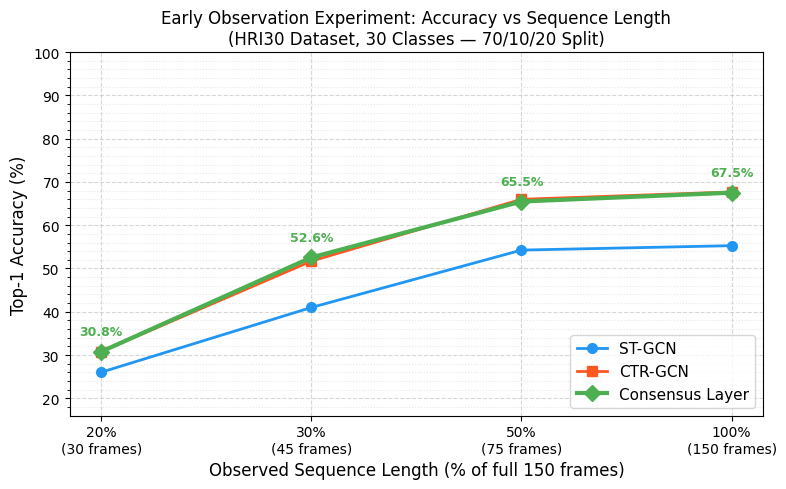


Plot saved to Drive: /content/drive/MyDrive/HRC_Research/results/temporal_truncation/temporal_truncation_plot_70_10_20.png
CSV saved to Drive:  /content/drive/MyDrive/HRC_Research/results/temporal_truncation/temporal_truncation_results_70_10_20.csv


In [5]:
# Print summary table and save plot to Drive (70/10/20 Split)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/temporal_truncation'
CSV_PATH   = os.path.join(OUTPUT_DIR, 'temporal_truncation_results_70_10_20.csv')

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found at {CSV_PATH}. Run Cell 4 first.")

df = pd.read_csv(CSV_PATH)

print("=" * 80)
print("TEMPORAL TRUNCATION RESULTS (Mean±Std, N=30 trials)")
print("HRI30 Test Set | 588 test samples | 30 classes | 70/10/20 Split")
print("=" * 80)
print(f"{'Obs. Ratio':<12} {'Frames':>8} {'ST-GCN':>14} {'CTR-GCN':>14} "
      f"{'Consensus':>15} {'Improvement':>13}")
print("-" * 80)

for _, row in df.iterrows():
    print(f"{row['observation_ratio']:<12} "
          f"{int(row['frames_kept']):>8} "
          f"{row['stgcn_mean']:>6.2f}±{row['stgcn_std']:>4.2f}  "
          f"{row['ctrgcn_mean']:>6.2f}±{row['ctrgcn_std']:>4.2f}  "
          f"{row['consensus_mean']:>7.2f}±{row['consensus_std']:>4.2f}  "
          f"{row['improvement_pp']:>+11.2f} pp")

print("=" * 80)
print("* Improvement = Consensus minus the stronger individual model at each ratio.")
print("* 100% observation matches the locked Phase 4 baseline (0% occlusion).")

# Plot
ratios      = df['observation_ratio'].tolist()
st_accs     = df['stgcn_mean'].tolist()
ctr_accs    = df['ctrgcn_mean'].tolist()
con_accs    = df['consensus_mean'].tolist()
x           = list(range(len(ratios)))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, st_accs,  marker='o', color='#2196F3', linewidth=2,
        markersize=7, label='ST-GCN')
ax.plot(x, ctr_accs, marker='s', color='#FF5722', linewidth=2,
        markersize=7, label='CTR-GCN')
ax.plot(x, con_accs, marker='D', color='#4CAF50', linewidth=3,
        markersize=8, label='Consensus Layer')

for i, val in enumerate(con_accs):
    ax.annotate(f'{val:.1f}%', xy=(i, val),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9,
                color='#4CAF50', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f"{r}\n({int(df.iloc[j]['frames_kept'])} frames)"
                    for j, r in enumerate(ratios)], fontsize=10)
ax.set_xlabel('Observed Sequence Length (% of full 150 frames)', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title('Early Observation Experiment: Accuracy vs Sequence Length\n'
             '(HRI30 Dataset, 30 Classes — 70/10/20 Split)',
             fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

min_val = min(min(st_accs), min(ctr_accs), min(con_accs))
ax.set_ylim(max(0, min_val - 10), 100)

plt.tight_layout()

PLOT_PATH = os.path.join(OUTPUT_DIR, 'temporal_truncation_plot_70_10_20.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to Drive: {PLOT_PATH}")
print(f"CSV saved to Drive:  {CSV_PATH}")